# DataAnalytics-L1-EDARetailSales

Run the code below from top to bottom.

DATASET OVERVIEW
Shape: (1200, 8)

Dtypes:
Date          datetime64[ns]
Product               object
Category              object
Age                    int64
Gender                object
Quantity               int64
Unit_Price           float64
Sales                float64
dtype: object

Null values:
Date          0
Product       0
Category      0
Age           0
Gender        0
Quantity      0
Unit_Price    0
Sales         0
dtype: int64

Duplicate rows: 0

DESCRIPTIVE STATISTICS


,Mean,Median,Mode,Standard Deviation
Age,40.854167,40.00,54.00,13.915433
Quantity,2.917500,3.00,1.00,1.422690
Unit_Price,224.552792,220.53,89.29,125.319128
Sales,654.897400,515.23,93.26,506.740581


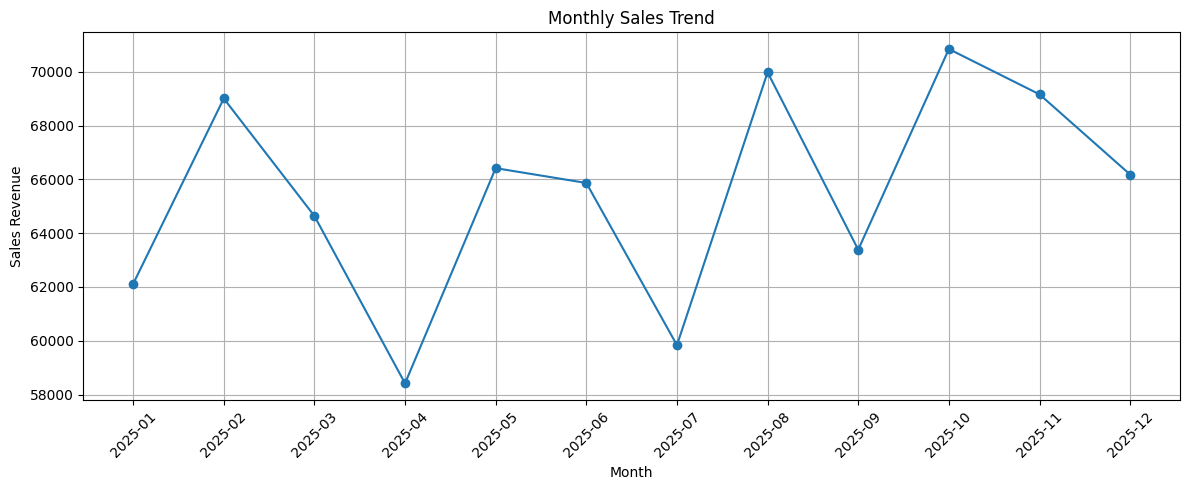


Observation:
Monthly sales trend shows how revenue changes over time.


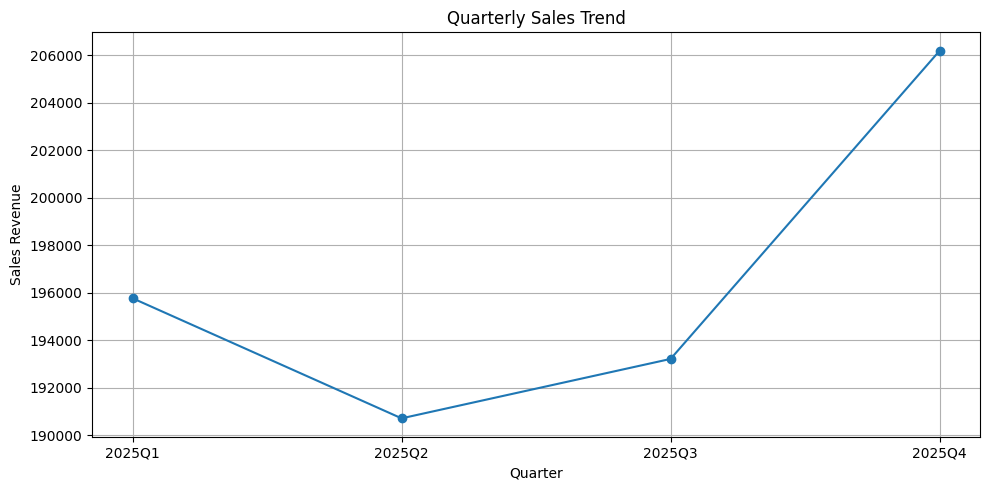


Observation:
Quarterly analysis helps identify high-performing and low-performing periods.


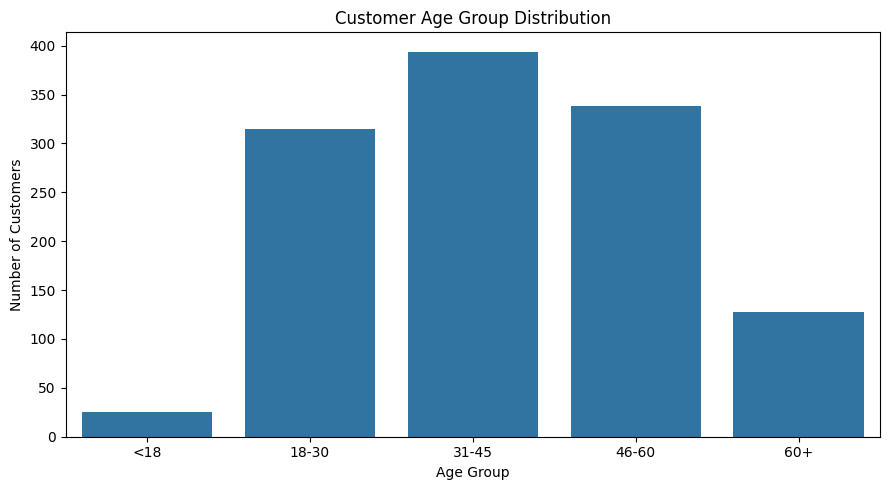


Observation:
The chart shows the distribution of customers across different age groups.


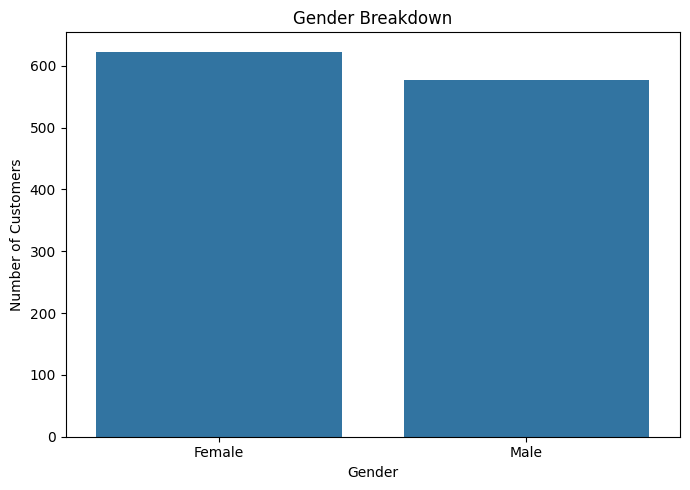


Observation:
The gender distribution provides insight into the customer composition.


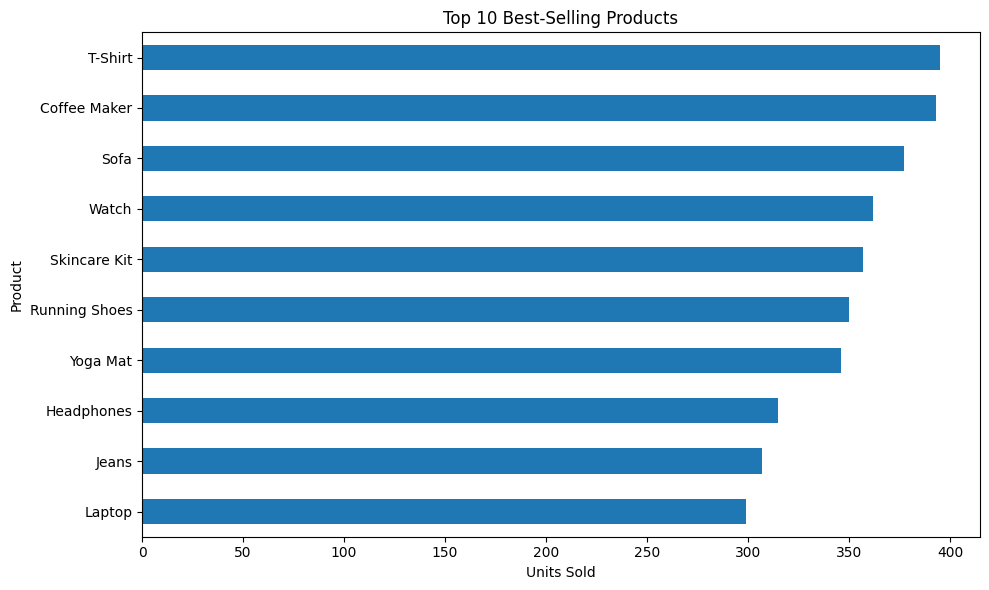


Observation:
The top products represent the items with the highest sales volume.


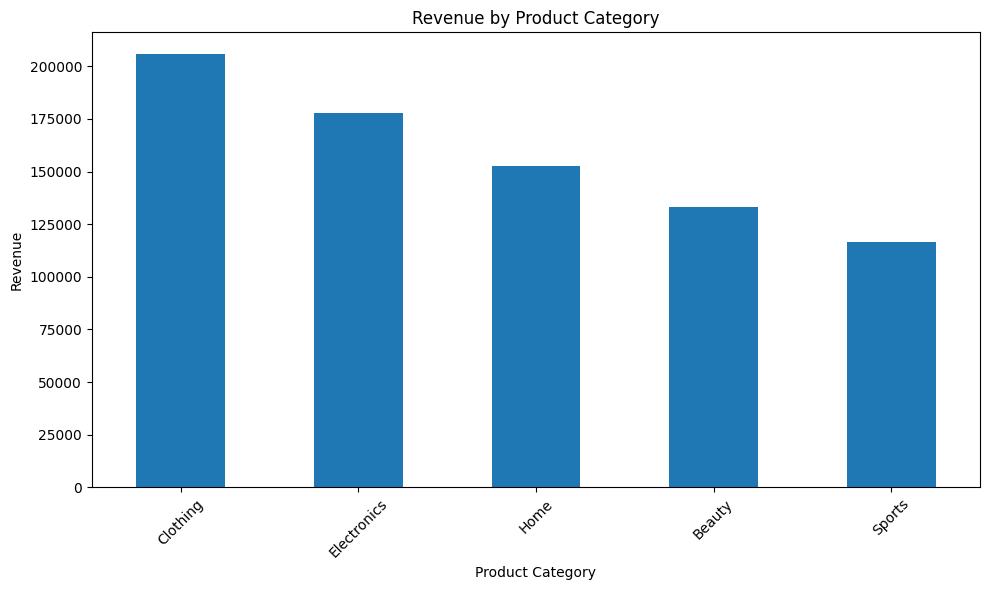


Observation:
The highest-revenue category is: Clothing


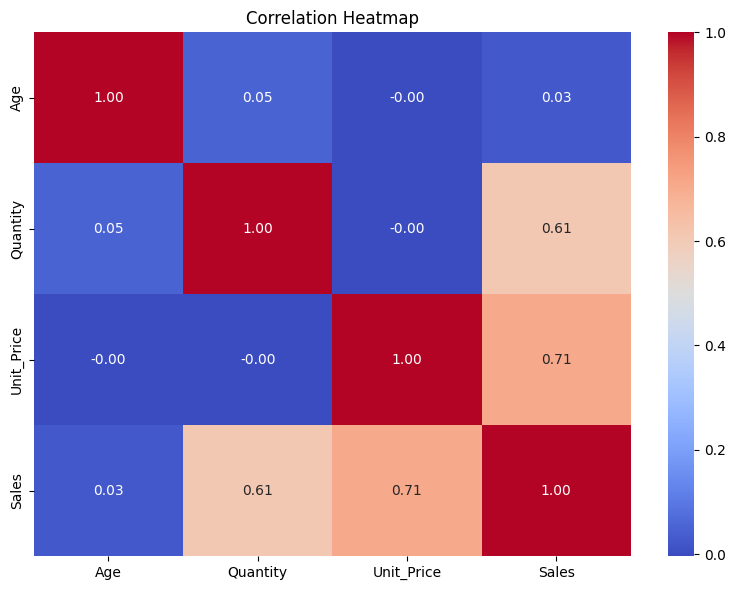


Observation:
The correlation heatmap shows relationships between numerical variables.


<Figure size 1000x600 with 0 Axes>

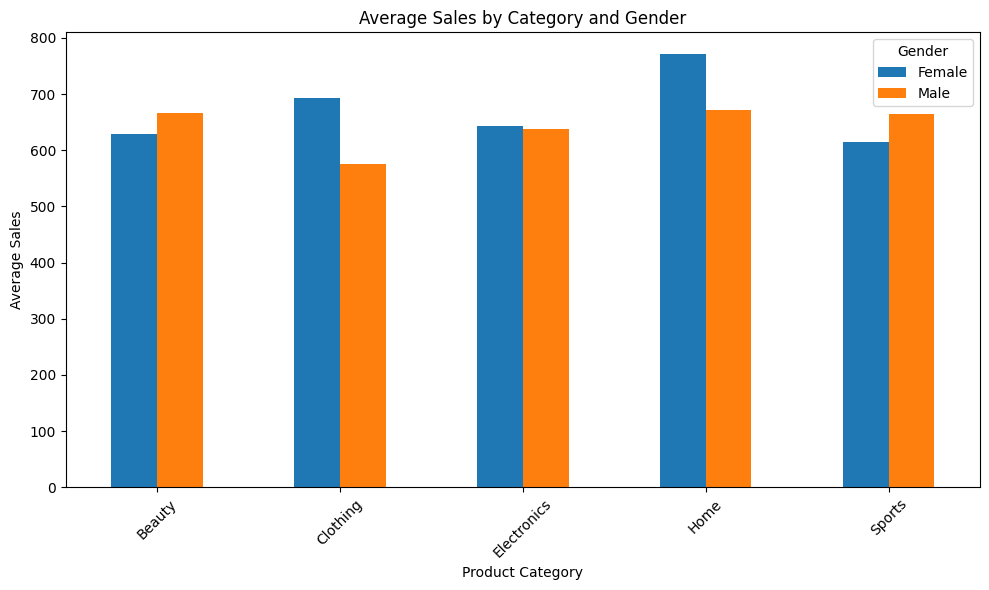


Additional Insight:
Average transaction value differs across product categories and genders, which can support targeted marketing strategies.

KEY FINDINGS
Total Revenue: 785,876.88
Average Transaction Value: 654.90
Total Units Sold: 3,501
Top Revenue Category: Clothing
Top-Selling Product: T-Shirt

ACTIONABLE BUSINESS RECOMMENDATIONS
1. Prioritize inventory and promotions for the highest-revenue category.
2. Use age and gender purchasing patterns to create targeted marketing campaigns.
3. Monitor monthly and quarterly sales peaks to plan inventory and marketing budgets in advance.

Summary saved to:
outputs/eda_summary.csv

EDA completed successfully!


In [4]:
# ============================================================
# OASIS INFOBYTE - DATA ANALYTICS
# TASK 1: EDA ON RETAIL SALES DATA
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

DATA_PATH = "dataset/retail_sales.csv"

df = pd.read_csv(DATA_PATH)

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print("Shape:", df.shape)

print("\nDtypes:")
print(df.dtypes)

print("\nNull values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


# ------------------------------------------------------------
# 2. DATA CLEANING
# ------------------------------------------------------------

df = df.drop_duplicates()

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Unit_Price"] = pd.to_numeric(df["Unit_Price"], errors="coerce")
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

df = df.dropna()

# Age groups
bins = [0, 18, 30, 45, 60, 100]
labels = ["<18", "18-30", "31-45", "46-60", "60+"]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


# ------------------------------------------------------------
# 3. DESCRIPTIVE STATISTICS
# ------------------------------------------------------------

numeric_cols = ["Age", "Quantity", "Unit_Price", "Sales"]

stats = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode": df[numeric_cols].mode().iloc[0],
    "Standard Deviation": df[numeric_cols].std()
})

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

display(stats)


# ------------------------------------------------------------
# 4. MONTHLY SALES TREND
# ------------------------------------------------------------

df["Month"] = df["Date"].dt.to_period("M").astype(str)

monthly_sales = (
    df.groupby("Month")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()


print("\nObservation:")
print("Monthly sales trend shows how revenue changes over time.")


# ------------------------------------------------------------
# 5. QUARTERLY SALES TREND
# ------------------------------------------------------------

df["Quarter"] = df["Date"].dt.to_period("Q").astype(str)

quarterly_sales = (
    df.groupby("Quarter")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    quarterly_sales["Quarter"],
    quarterly_sales["Sales"],
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales Revenue")
plt.grid(True)
plt.tight_layout()

plt.show()


print("\nObservation:")
print("Quarterly analysis helps identify high-performing and low-performing periods.")


# ------------------------------------------------------------
# 6. CUSTOMER AGE GROUP ANALYSIS
# ------------------------------------------------------------

age_counts = df["Age_Group"].value_counts().sort_index()

plt.figure(figsize=(9, 5))

sns.barplot(
    x=age_counts.index,
    y=age_counts.values
)

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.show()


print("\nObservation:")
print("The chart shows the distribution of customers across different age groups.")


# ------------------------------------------------------------
# 7. GENDER ANALYSIS
# ------------------------------------------------------------

gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Gender Breakdown")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.show()


print("\nObservation:")
print("The gender distribution provides insight into the customer composition.")


# ------------------------------------------------------------
# 8. TOP 10 BEST-SELLING PRODUCTS
# ------------------------------------------------------------

top10 = (
    df.groupby("Product")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

top10.plot(kind="barh")

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.tight_layout()

plt.show()


print("\nObservation:")
print("The top products represent the items with the highest sales volume.")


# ------------------------------------------------------------
# 9. REVENUE BY PRODUCT CATEGORY
# ------------------------------------------------------------

category_revenue = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


print("\nObservation:")
print(
    "The highest-revenue category is:",
    category_revenue.idxmax()
)


# ------------------------------------------------------------
# 10. CORRELATION HEATMAP
# ------------------------------------------------------------

corr_cols = [
    "Age",
    "Quantity",
    "Unit_Price",
    "Sales"
]

correlation = df[corr_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.show()


print("\nObservation:")
print(
    "The correlation heatmap shows relationships between numerical variables."
)


# ------------------------------------------------------------
# 11. ADDITIONAL NON-OBVIOUS INSIGHT
# ------------------------------------------------------------

gender_category = (
    df.groupby(["Category", "Gender"])["Sales"]
    .mean()
    .unstack()
)

plt.figure(figsize=(10, 6))

gender_category.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Sales by Category and Gender")
plt.xlabel("Product Category")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


print("\nAdditional Insight:")
print(
    "Average transaction value differs across product categories and genders, "
    "which can support targeted marketing strategies."
)


# ------------------------------------------------------------
# 12. KEY BUSINESS FINDINGS
# ------------------------------------------------------------

total_revenue = df["Sales"].sum()
average_transaction = df["Sales"].mean()
total_units = df["Quantity"].sum()

top_category = category_revenue.idxmax()

top_product = (
    df.groupby("Product")["Quantity"]
    .sum()
    .idxmax()
)

print("\n" + "=" * 60)
print("KEY FINDINGS")
print("=" * 60)

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Average Transaction Value: {average_transaction:,.2f}")
print(f"Total Units Sold: {total_units:,}")
print(f"Top Revenue Category: {top_category}")
print(f"Top-Selling Product: {top_product}")


# ------------------------------------------------------------
# 13. ACTIONABLE BUSINESS RECOMMENDATIONS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ACTIONABLE BUSINESS RECOMMENDATIONS")
print("=" * 60)

print("1. Prioritize inventory and promotions for the highest-revenue category.")

print(
    "2. Use age and gender purchasing patterns to create targeted "
    "marketing campaigns."
)

print(
    "3. Monitor monthly and quarterly sales peaks to plan inventory "
    "and marketing budgets in advance."
)


# ------------------------------------------------------------
# 14. SAVE SUMMARY OUTPUT
# ------------------------------------------------------------

os.makedirs("outputs", exist_ok=True)
os.makedirs("visualizations", exist_ok=True)

summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Average Transaction Value",
        "Total Units Sold",
        "Top Revenue Category",
        "Top-Selling Product"
    ],
    "Value": [
        total_revenue,
        average_transaction,
        total_units,
        top_category,
        top_product
    ]
})

summary.to_csv(
    "outputs/eda_summary.csv",
    index=False
)

print("\nSummary saved to:")
print("outputs/eda_summary.csv")

print("\nEDA completed successfully!")